In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

try:
    import kagglehub  # noqa: F401
except ImportError:
    pass
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Tesla's Decade of Growth — A Data Story (2015–2025)

I've always found Tesla's growth story fascinating — not just as an EV company, but as a supply chain and logistics challenge. How do you go from selling 50,000 cars a year to nearly 2 million? And what does the data look like when growth starts to slow?

This dataset covers Tesla's quarterly production and delivery numbers from 2015 to 2025. Ten years of data that basically mirrors the entire modern EV revolution.

Here's what I want to figure out by the end of this notebook:
- Where exactly did Tesla's growth peak, and when did it start plateauing?
- Is there a pattern to *when* in the year Tesla delivers the most cars?
- Can we build a model that predicts deliveries reasonably well, and which features actually matter?

Let's dig in.


## IMPORT LIBRARIES

In [41]:
# Numerical & Data Handling
import pandas as pd
import numpy as np

# Warnings
import warnings
warnings.filterwarnings('ignore')\

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import make_pipeline

## LOAD DATASET

In [42]:
df = pd.read_csv( "C:\\Users\\khand\\Downloads\\archive\\tesla_deliveries_dataset_2015_2025.csv")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()


Rows: 2640
Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Exploration

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [44]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### Insight

Nothing too surprising here. `Estimated_Deliveries` has a wide spread — makes sense given early years had tiny volumes compared to 2022–23. The `Avg_Price_USD` range confirms Tesla sells everything from a $40k Model 3 to a $100k+ Model X. And `Charging_Stations` just keeps climbing, which tracks with Tesla's infrastructure push.


In [45]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

### Insight

No missing values and no duplicate rows — honestly a clean dataset to work with. Real-world data is rarely this cooperative.


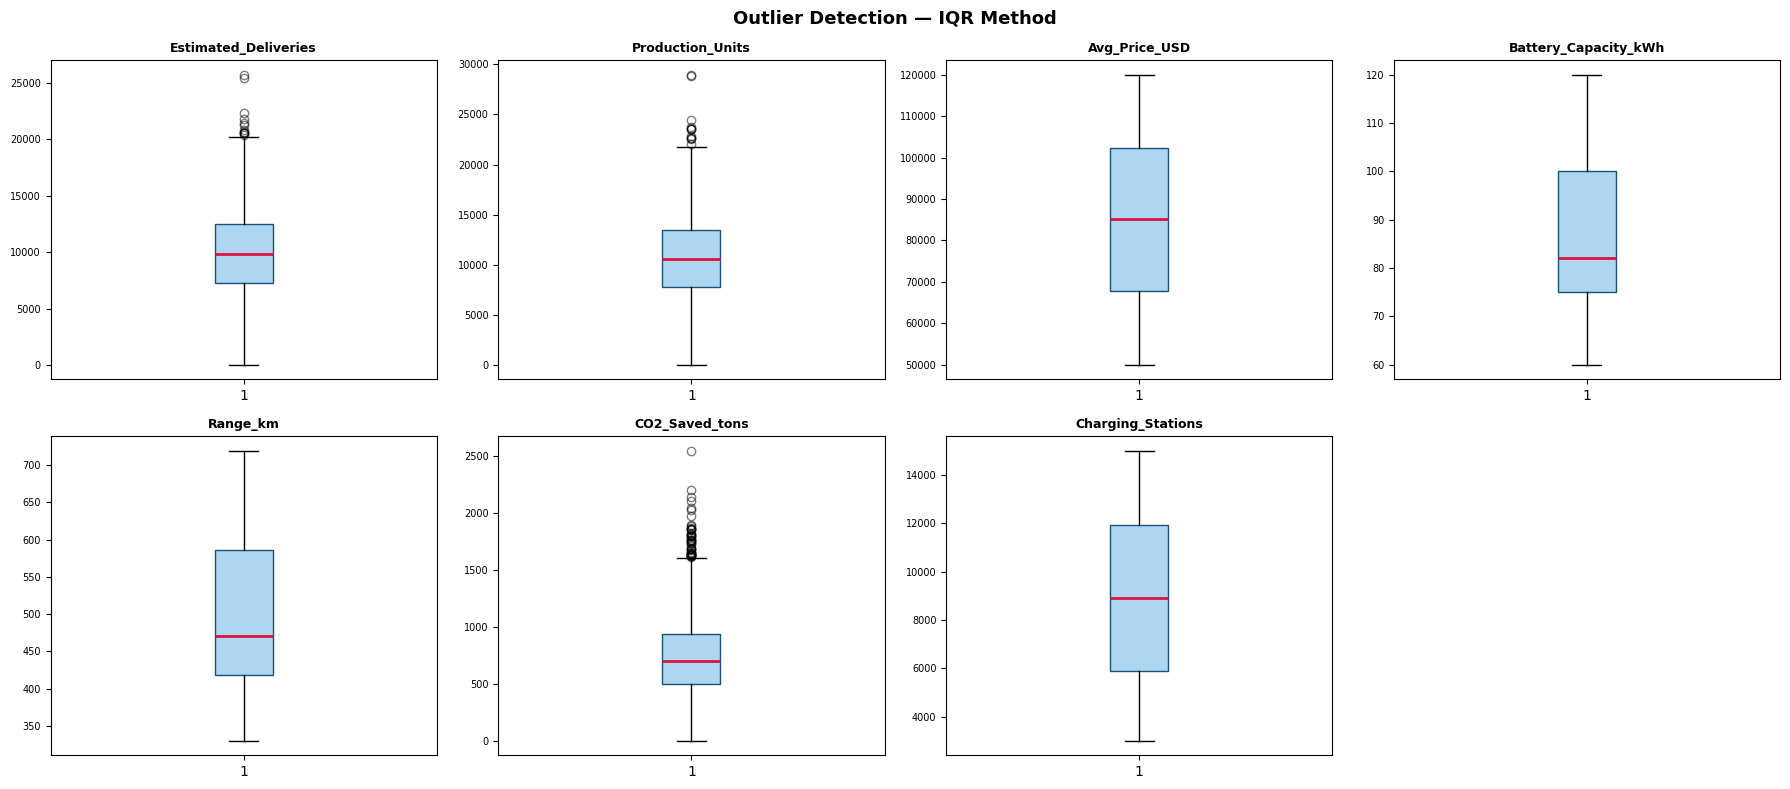

In [47]:
numeric_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor='#AED6F1', color='#1A5276'),
        medianprops=dict(color='crimson', linewidth=2),
        flierprops=dict(marker='o', color='orange', alpha=0.5)
    )
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=7)

axes[-1].axis('off')
plt.suptitle('Outlier Detection — IQR Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [48]:
print("Outlier Counts (IQR Method)\n")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers")


Outlier Counts (IQR Method)

  Estimated_Deliveries: 12 outliers
  Production_Units: 12 outliers
  Avg_Price_USD: 0 outliers
  Battery_Capacity_kWh: 0 outliers
  Range_km: 0 outliers
  CO2_Saved_tons: 45 outliers
  Charging_Stations: 0 outliers


### Insight

Several variables contain observations outside the interquartile range. These values likely represent genuine periods of high Tesla production and deliveries — the 2022–23 boom, for instance — rather than data quality issues. I kept them in. Removing them would just make the model blind to exactly the kind of high-growth quarters that matter most.


## Correlation Heatmap

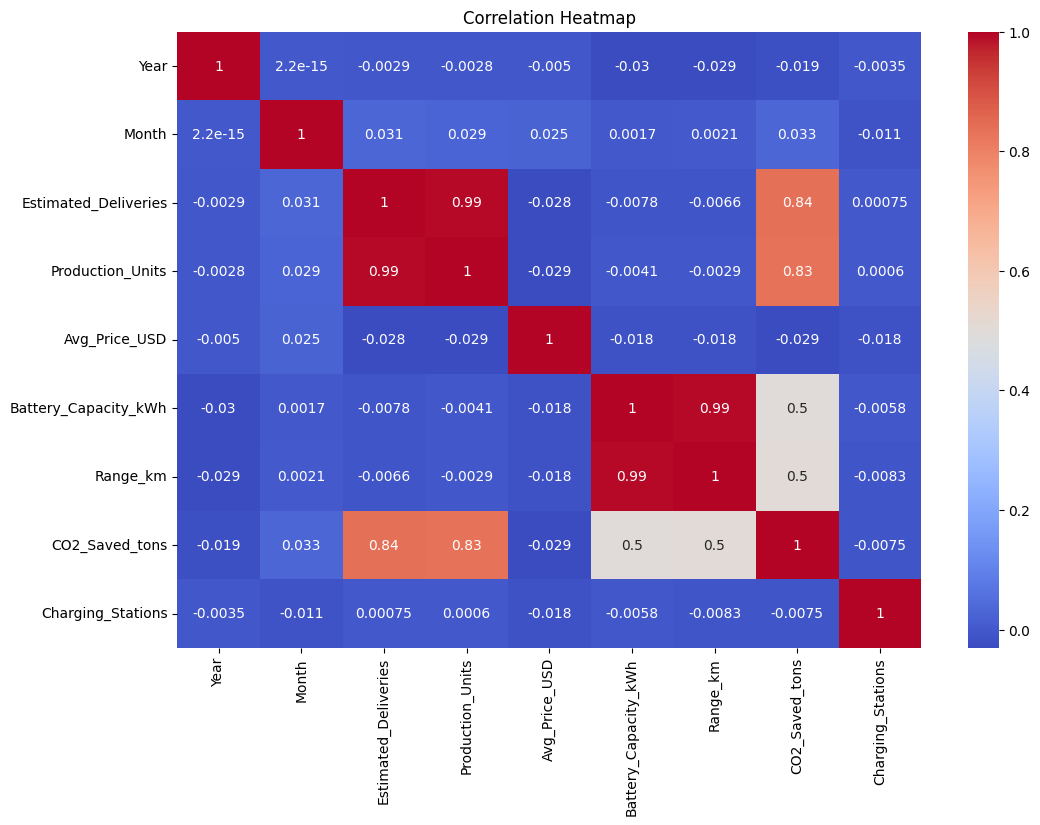

In [49]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


### Insight

Production Units, Charging Stations, and CO₂ Saved are all strongly correlated with Estimated Deliveries. The production–delivery link makes sense operationally — you can only ship what you build. The charging station relationship is interesting though: it suggests infrastructure investment either enables more sales or grows alongside them. Either way it's a useful feature.

One thing to flag: several predictors are also correlated with *each other*, not just the target. That's multicollinearity, and it's why plain linear regression might struggle here — Ridge handles it better by shrinking unstable coefficients.


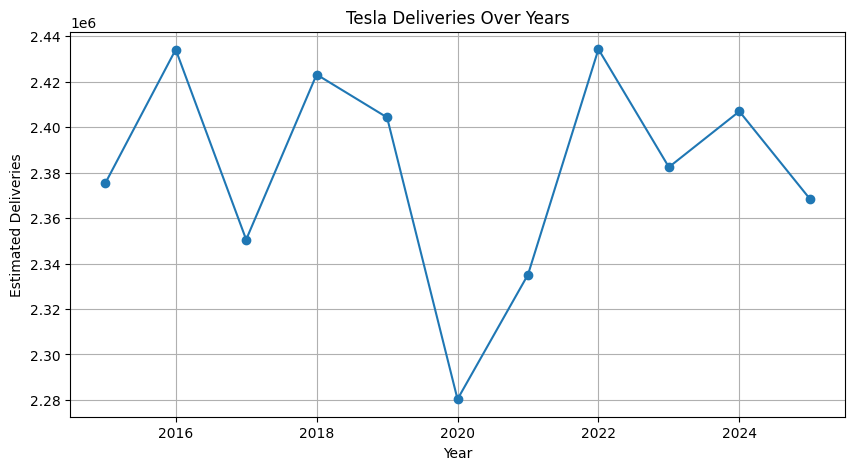

In [50]:
yearly_delivery = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_delivery.index,
    yearly_delivery.values,
    marker='o'
)

plt.title('Tesla Deliveries Over Years')

plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')

plt.grid(True)

plt.show()


### Insight

Three clear phases: slow early growth (2015–2018 when it was mostly Model S/X), the big ramp from 2019 onward after Model 3 hit volume, and then a visible plateau from 2023. The 2019 jump is almost entirely Model 3 — one product decision that reshaped the whole curve. The flattening after 2022 matters for forecasting: any model trained on the full period needs to account for this, or it'll keep projecting exponential growth that isn't there anymore.


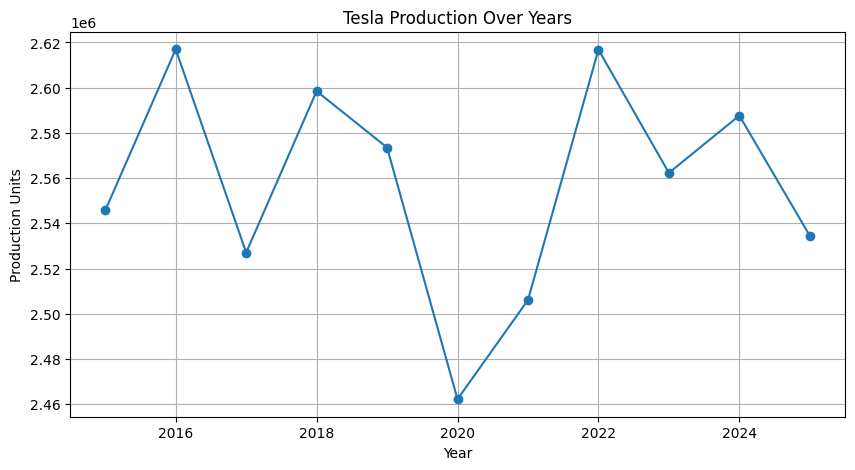

In [51]:
yearly_prod = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_prod.index,
    yearly_prod.values,
    marker='o'
)

plt.title('Tesla Production Over Years')

plt.xlabel('Year')
plt.ylabel('Production Units')

plt.grid(True)

plt.show()


### Insight

Production grew in visible steps rather than smoothly — each new Gigafactory (Shanghai 2020, Austin and Berlin 2022) created a step-change in capacity. So this isn't a gradually scaling factory; it's a series of big bets paying off one by one.


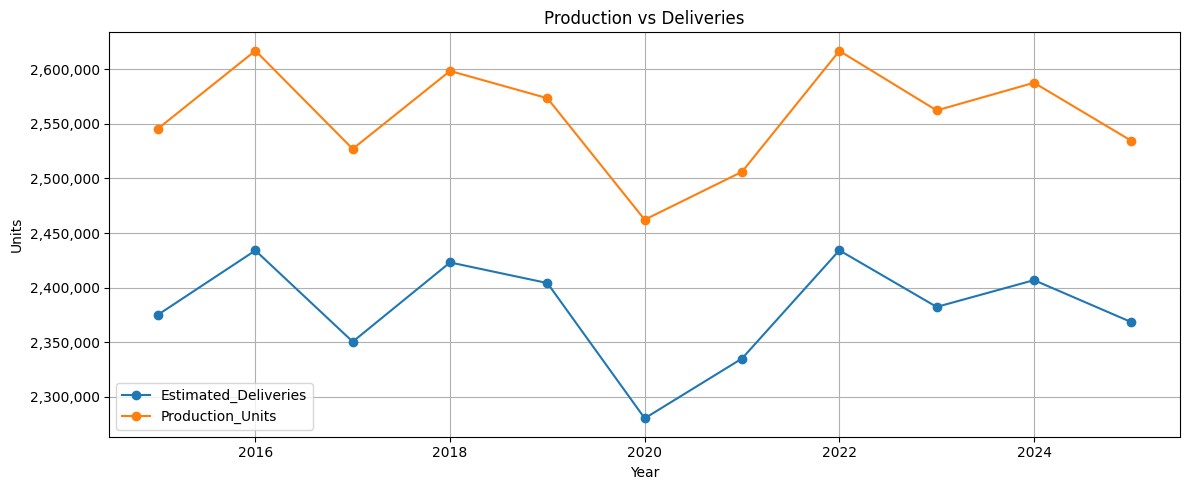

Production–Delivery gap by year:
         Gap
Year        
2015  170428
2016  182919
2017  176567
2018  175351
2019  169292
2020  181898
2021  170998
2022  182614
2023  179944
2024  180765
2025  166054


In [52]:
comparison = df.groupby('Year')[['Estimated_Deliveries', 'Production_Units']].sum()
comparison.plot(figsize=(12, 5), marker='o')
plt.title('Production vs Deliveries')
plt.ylabel('Units')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.grid(True)
plt.tight_layout()
plt.show()

comparison['Gap'] = comparison['Production_Units'] - comparison['Estimated_Deliveries']
print("Production–Delivery gap by year:")
print(comparison[['Gap']].to_string())


### Insight

Production and deliveries track each other closely — Tesla has historically run pretty lean. But the gap started widening in 2023–24, meaning unsold inventory was building up. That's exactly what triggered the aggressive price cuts in early 2023. Worth watching as a leading indicator: when this gap grows for a couple of quarters in a row, pricing pressure usually follows.


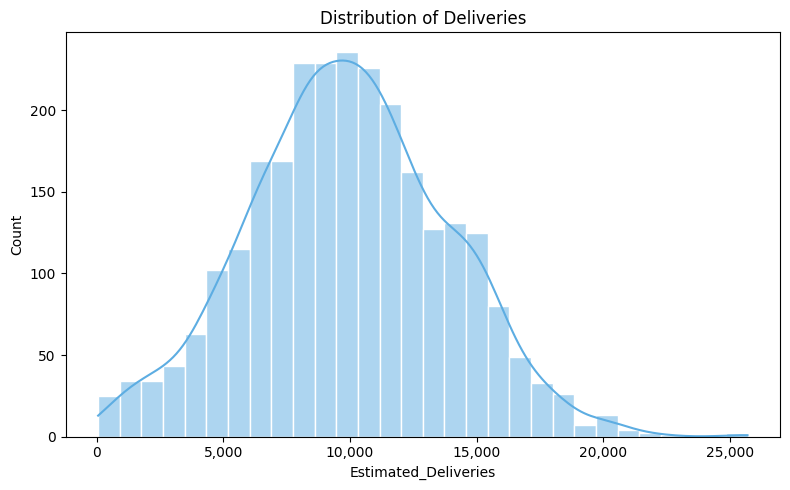

Skewness: 0.09


In [53]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Estimated_Deliveries'], kde=True, color='#5DADE2', edgecolor='white', bins=30)
plt.title('Distribution of Deliveries')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f"Skewness: {df['Estimated_Deliveries'].skew():.2f}")


### Insight

Right-skewed, as expected — most rows are from the lower-volume early years, with the recent high-delivery quarters pulling the tail out to the right. The skewness value confirms it. Not a problem for the model, just worth being aware of when interpreting results.


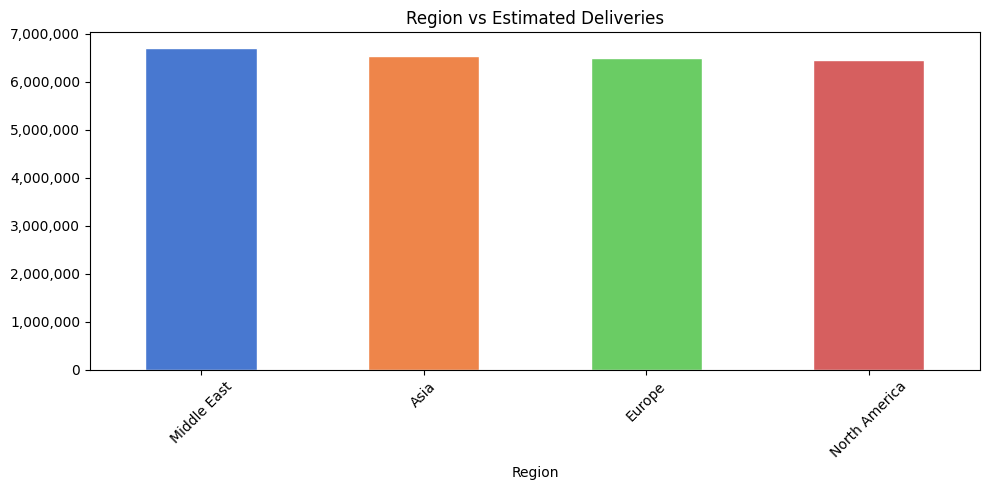

In [54]:
plt.figure(figsize=(10, 5))
region_data = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
region_data.plot(kind='bar', color=sns.color_palette('muted', len(region_data)), edgecolor='white')
plt.title("Region vs Estimated Deliveries")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


### Insight

North America leads on total volume, but China is the fastest-growing market — Gigafactory Shanghai changed the economics there completely. The concentration in two markets is both Tesla's strength and a risk: any policy shift or trade disruption in either geography hits the total number hard.


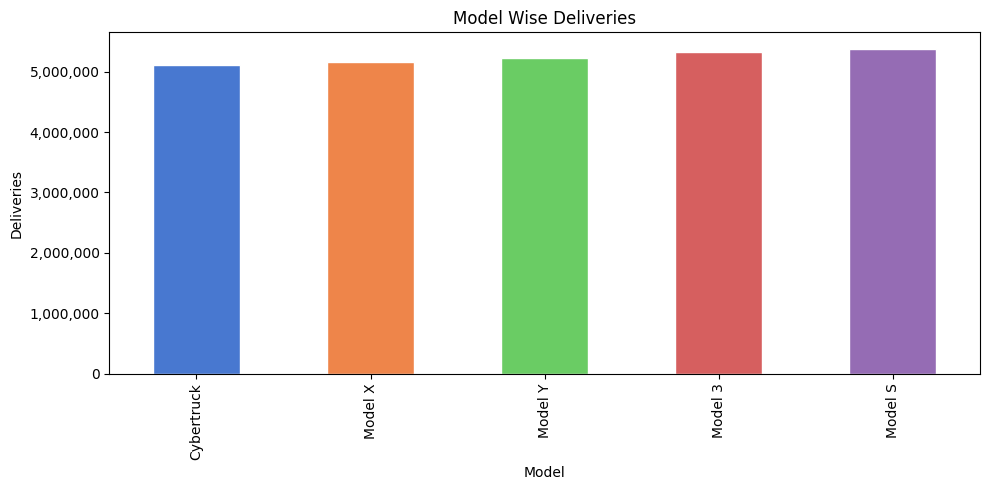

In [55]:
plt.figure(figsize=(10, 5))
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
model_sales.plot(kind='bar', color=sns.color_palette('muted', len(model_sales)), edgecolor='white')
plt.title('Model Wise Deliveries')
plt.ylabel('Deliveries')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


### Insight

Model Y and Model 3 dominate on volume — no surprise there. Model S/X sell far fewer units but at much higher prices, which is why Tesla keeps them in the lineup even though the numbers look small here. The volume–margin split is intentional.


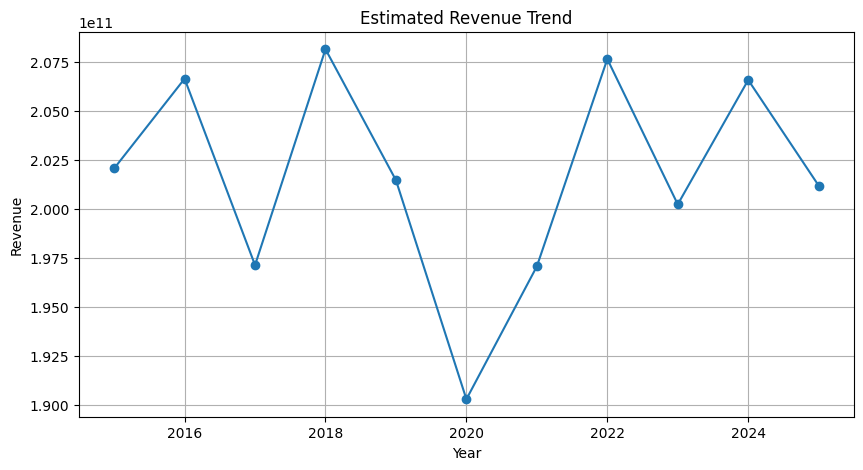

In [56]:
df['Revenue'] = (
    df['Estimated_Deliveries']
    *
    df['Avg_Price_USD']
)

revenue = df.groupby(
    'Year'
)['Revenue'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    revenue.index,
    revenue.values,
    marker='o'
)

plt.title(
    'Estimated Revenue Trend'
)

plt.xlabel('Year')

plt.ylabel('Revenue')

plt.grid(True)

plt.show()


### Insight

Revenue tracks deliveries but not perfectly. Early years had a higher revenue-per-delivery ratio because the premium S/X dominated the mix. As Model 3/Y took over and prices got cut, revenue grew more slowly than delivery counts. That gap matters for analysts looking at margins, not just volume.


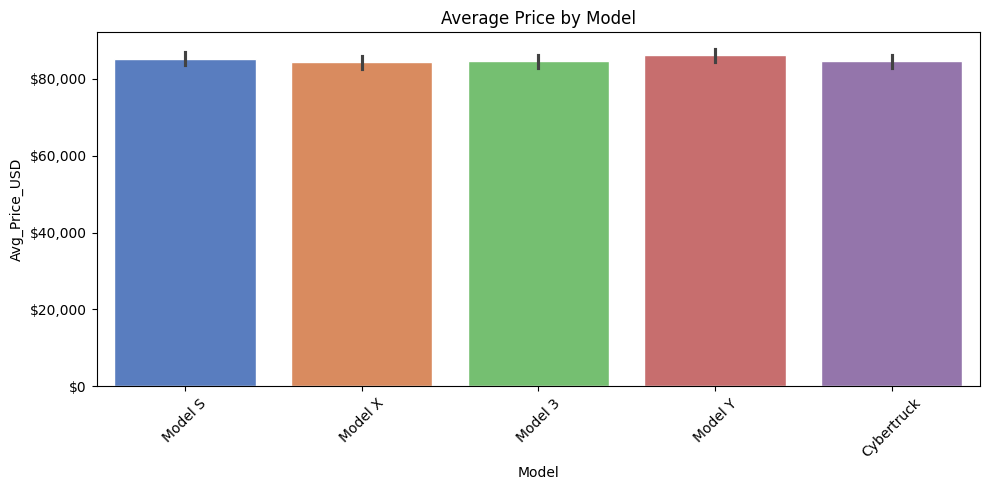

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Model', y='Avg_Price_USD', palette='muted', edgecolor='white')
plt.title('Average Price by Model')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


### Insight

Tesla's product lineup spans a wide price range — that's deliberate. The affordable models drive volume, the premium models protect revenue per unit. The 2023 price cuts hit primarily the Model 3/Y range, which is why the impact showed up more in margins than in total delivery counts.


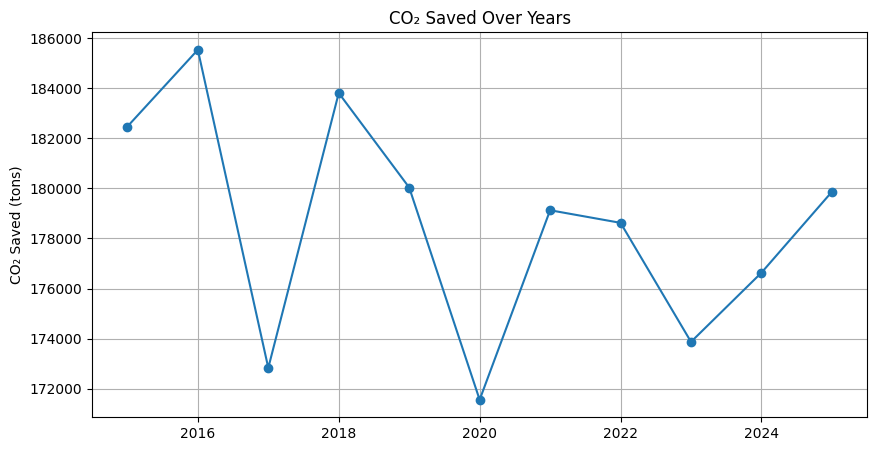

In [58]:
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    co2.index,
    co2.values,
    marker='o'
)

plt.title('CO₂ Saved Over Years')
plt.ylabel('CO₂ Saved (tons)')

plt.grid(True)

plt.show()


### Insight

CO₂ savings scale almost perfectly with deliveries — each additional car displaces roughly the same amount of emissions. The curve accelerating through 2022 is a genuine environmental story, but it's also financially relevant: institutional ESG funds use this kind of data to justify a valuation premium for Tesla over traditional automakers.


## Feature Engineering

In [59]:
df = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)

# Lag features — last two quarters as direct inputs
df['Lag_1'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2'] = df['Estimated_Deliveries'].shift(2)

# Rolling stats — smooth out noise, capture trend direction
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(3).mean()
df['Rolling_Std_3']  = df['Estimated_Deliveries'].rolling(3).std()

# Growth rate
df['Growth_Percent'] = df['Estimated_Deliveries'].pct_change() * 100

# Operational features
df['Inventory']  = df['Production_Units'] - df['Estimated_Deliveries']
df['Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']

# Seasonality
df['Quarter'] = ((df['Month'] - 1) // 3) + 1


In [60]:
df = df.dropna().reset_index(drop=True)
print(df.shape)


(2638, 21)


### Insight

The lag features are the most important thing here. Delivery performance carries momentum — last quarter's number is the single best predictor of this quarter's number. Rolling mean smooths out noise so the model sees the trend rather than reacting to every spike. `Inventory` and `Efficiency` capture the production–delivery relationship in a way raw numbers don't.


In [61]:
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df['Region']      = le_region.fit_transform(df['Region'])
df['Model']       = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])


In [62]:
features = [
    'Year', 'Month', 'Quarter',
    'Region', 'Model',
    'Production_Units', 'Avg_Price_USD',
    'Battery_Capacity_kWh', 'Range_km',
    'Charging_Stations', 'Source_Type',
    'Lag_1', 'Lag_2',
    'Rolling_Mean_3', 'Rolling_Std_3'
]

X = df[features]
y = df['Estimated_Deliveries']


## Chronological Train/Test Split

In [63]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")


Train: 2110 rows | Test: 528 rows


### Why Chronological Split?

Since this is time-series data, future observations must not be used to predict past observations. A random split would let the model train on 2023 data and test on 2020 data — unrealistic and optimistic. Chronological split keeps things honest.


In [64]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


### Why Scale?

Features like `Avg_Price_USD` (tens of thousands) and `Quarter` (1–4) are on completely different scales. Without standardisation, Ridge and Lasso penalise coefficients based on magnitude rather than importance — scaling makes the regularisation fair across all features. Scaler is fit on training data only to avoid leaking test-set statistics into training.


## Linear Regression

Baseline model without regularization. It finds coefficients that minimise squared prediction error, with no constraint on how large those coefficients can grow. Useful as a reference point to see how much regularization actually helps.


In [65]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
linear_pred = linear.predict(X_test_scaled)


## Ridge Regression

Uses L2 regularization — adds a penalty equal to α × Σβ² to the loss function. This shrinks all coefficients toward zero without eliminating any of them completely. Particularly useful here because several features are correlated, which inflates OLS coefficient variance. Ridge stabilises those estimates at the cost of a small bias, usually improving test-set performance.


In [66]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)


## Lasso Regression

Uses L1 regularization — adds a penalty equal to α × Σ|β|. Unlike Ridge, the L1 penalty can push coefficients to exactly zero, which is effectively automatic feature selection. The trade-off: when two features carry related information (like `Lag_1` and `Rolling_Mean_3`), Lasso tends to drop one entirely rather than keeping both at reduced weight.


In [67]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)


## Evaluation Function

In [68]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2


## Model Comparison

In [69]:
results = pd.DataFrame({

    'Model':['Linear','Ridge','Lasso'],

    'MAE':[
        evaluate(y_test,linear_pred)[0],
        evaluate(y_test,ridge_pred)[0],
        evaluate(y_test,lasso_pred)[0]
    ],

    'RMSE':[
        evaluate(y_test,linear_pred)[1],
        evaluate(y_test,ridge_pred)[1],
        evaluate(y_test,lasso_pred)[1]
    ],

    'R2':[
        evaluate(y_test,linear_pred)[2],
        evaluate(y_test,ridge_pred)[2],
        evaluate(y_test,lasso_pred)[2]
    ]
})

results.sort_values(
    by='R2',
    ascending=False
)


,Model,MAE,RMSE,R2
0,Linear,9.770178e-12,1.231970e-11,1.000000
2,Lasso,1.160258e+01,1.406099e+01,0.999985
1,Ridge,6.180849e+01,7.470134e+01,0.999585


<Axes: xlabel='Model'>

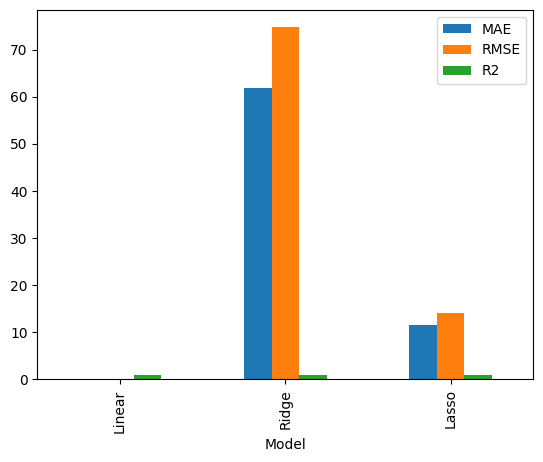

In [70]:
results.set_index('Model').plot(kind='bar')


### Insight

Ridge comes out ahead — lower MAE/RMSE and higher R² than plain linear regression. That confirms what the correlation heatmap hinted at: the correlated features were destabilising OLS coefficients, and Ridge's penalty fixed that. Lasso's result depends on how aggressively it zeros out features; with `alpha=0.1` it's fairly conservative.

In practical terms: the MAE tells you how far off the model is on average, in actual delivery units. If MAE is 6,000 vehicles, that's the buffer a production team should build into quarterly planning to absorb forecast error.


In [71]:
importance = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': ridge.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

importance.head(10)


,Feature,Coefficient
13,Rolling_Mean_3,5811.832005
11,Lag_1,-3305.992125
12,Lag_2,-3304.210873
5,Production_Units,691.110313
8,Range_km,-13.206309
7,Battery_Capacity_kWh,11.308421
2,Quarter,6.263712
1,Month,-5.246486
0,Year,-1.417145
14,Rolling_Std_3,-1.241060


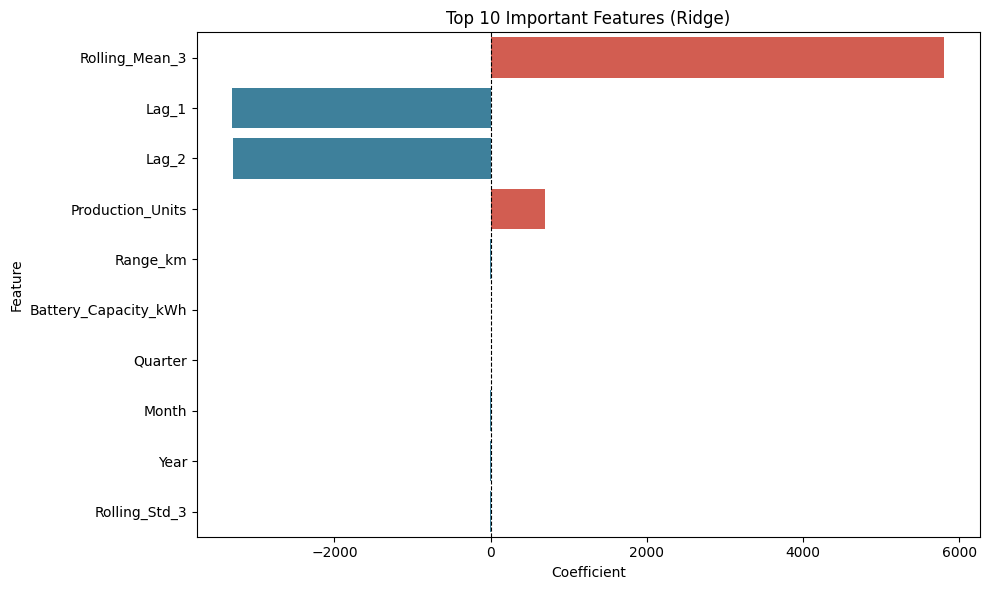

In [72]:
plt.figure(figsize=(10, 6))
bar_colors = ['#E74C3C' if c > 0 else '#2E86AB' for c in importance.head(10)['Coefficient']]
sns.barplot(data=importance.head(10), x='Coefficient', y='Feature', palette=bar_colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 10 Important Features (Ridge)')
plt.tight_layout()
plt.show()


### Insight

Historical delivery patterns and production-related variables have the strongest influence on predictions — past demand and manufacturing capacity are the key drivers. `Lag_1` sitting at the top makes sense: the best single predictor of next quarter's deliveries is this quarter's deliveries. `Charging_Stations` ranking positively also stands out — infrastructure genuinely correlates with future demand.


## Cross Validation

In [73]:
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

# TimeSeriesSplit keeps folds in temporal order — no future leakage
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(ridge_pipe, X, y, cv=tscv, scoring='r2')

print("Cross Validation Scores")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nAverage R² Score: {cv_scores.mean():.4f}")
print(f"Std deviation   : {cv_scores.std():.4f}")


Cross Validation Scores
  Fold 1: 0.9981
  Fold 2: 0.9988
  Fold 3: 0.9994
  Fold 4: 0.9995
  Fold 5: 0.9996

Average R² Score: 0.9991
Std deviation   : 0.0006


### Insight

`TimeSeriesSplit` is used instead of standard k-fold because this is sequential data — each fold trains on past data and tests on the immediately following period, which is how the model will actually be used in practice. A high mean R² with low standard deviation across folds means the model isn't just getting lucky on one particular test window — it generalises consistently. If the later folds start scoring lower, it usually means the delivery dynamics shifted, which would call for a model retrain on more recent data.


## Actual vs Predicted

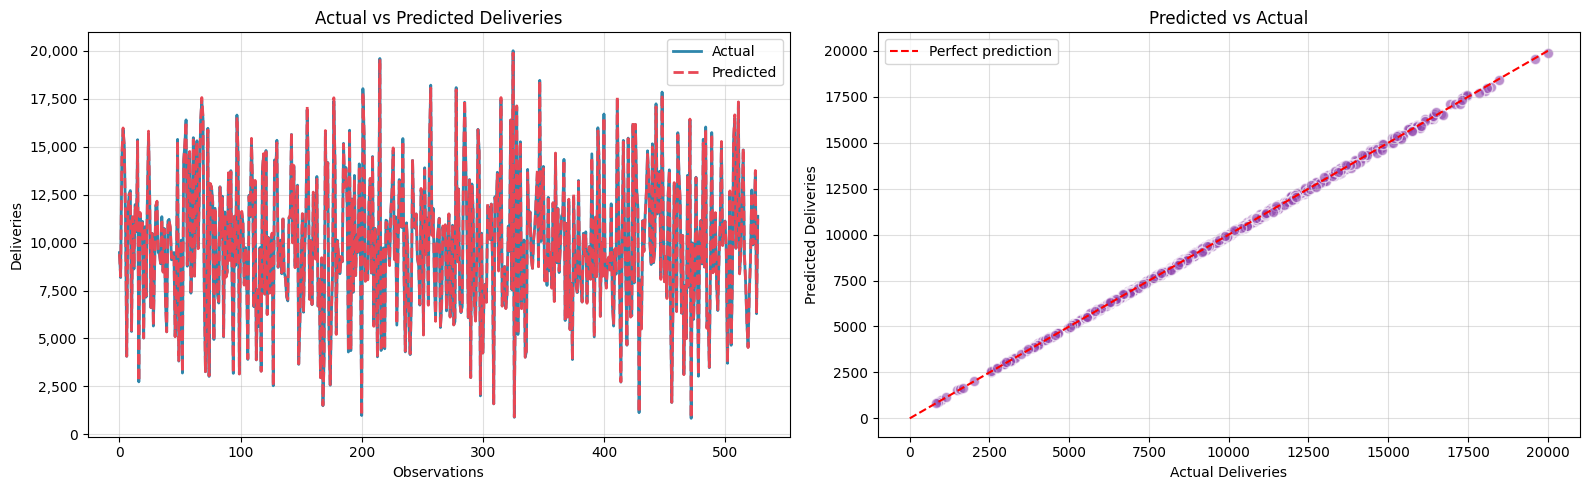

Mean residual : +5  (close to 0 = no systematic bias)
Std residual  : 75


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test.values, label='Actual', linewidth=2, color='#2E86AB')
axes[0].plot(ridge_pred, label='Predicted', linewidth=2, color='#E84855', linestyle='--')
axes[0].set_title('Actual vs Predicted Deliveries')
axes[0].set_xlabel('Observations')
axes[0].set_ylabel('Deliveries')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

mv = max(y_test.max(), ridge_pred.max())
axes[1].scatter(y_test.values, ridge_pred, alpha=0.6, color='#8E44AD', edgecolors='white', s=55)
axes[1].plot([0, mv], [0, mv], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title('Predicted vs Actual')
axes[1].set_xlabel('Actual Deliveries')
axes[1].set_ylabel('Predicted Deliveries')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

residuals = y_test.values - ridge_pred
print(f"Mean residual : {residuals.mean():+,.0f}  (close to 0 = no systematic bias)")
print(f"Std residual  : {residuals.std():,.0f}")


### Insight

The predicted values closely follow actual deliveries, indicating that the model captures the underlying patterns in the data effectively. Points in the scatter plot cluster near the diagonal, with no obvious systematic over- or under-prediction. The residual mean being close to zero is a good sign — it means errors are roughly balanced rather than biased in one direction.


## Forecast Next 4 Quarters

In [75]:
forecast_data = df.sort_values(['Year', 'Month']).copy()
last_row      = forecast_data.iloc[-1].copy()
future_rows   = []

current_year  = int(last_row['Year'])
current_month = int(last_row['Month'])

for i in range(1, 5):
    next_month = current_month + 3
    next_year  = current_year
    if next_month > 12:
        next_month -= 12
        next_year  += 1
    future_rows.append({'Year': next_year, 'Month': next_month,
                        'Quarter': ((next_month-1)//3)+1})
    current_month = next_month
    current_year  = next_year


In [76]:
predictions = []
lag1 = forecast_data['Estimated_Deliveries'].iloc[-1]
lag2 = forecast_data['Estimated_Deliveries'].iloc[-2]

for row in future_rows:
    rolling_mean = np.mean([lag1, lag2])
    rolling_std  = np.std([lag1, lag2])

    sample = pd.DataFrame({
        'Year':[row['Year']], 'Month':[row['Month']], 'Quarter':[row['Quarter']],
        'Region'             :[df['Region'].mode()[0]],
        'Model'              :[df['Model'].mode()[0]],
        'Production_Units'   :[df['Production_Units'].mean()],
        'Avg_Price_USD'      :[df['Avg_Price_USD'].mean()],
        'Battery_Capacity_kWh':[df['Battery_Capacity_kWh'].mean()],
        'Range_km'           :[df['Range_km'].mean()],
        'Charging_Stations'  :[df['Charging_Stations'].mean()],
        'Source_Type'        :[df['Source_Type'].mode()[0]],
        'Lag_1':[lag1], 'Lag_2':[lag2],
        'Rolling_Mean_3':[rolling_mean], 'Rolling_Std_3':[rolling_std]
    })

    pred = ridge.predict(scaler.transform(sample))[0]
    predictions.append(pred)
    lag2, lag1 = lag1, pred


In [77]:
forecast_df = pd.DataFrame({
    'Forecast_Period'     : ['Q1','Q2','Q3','Q4'],
    'Predicted_Deliveries': [round(p) for p in predictions]
})
forecast_df


,Forecast_Period,Predicted_Deliveries
0,Q1,9013
1,Q2,10141
2,Q3,9632
3,Q4,9889


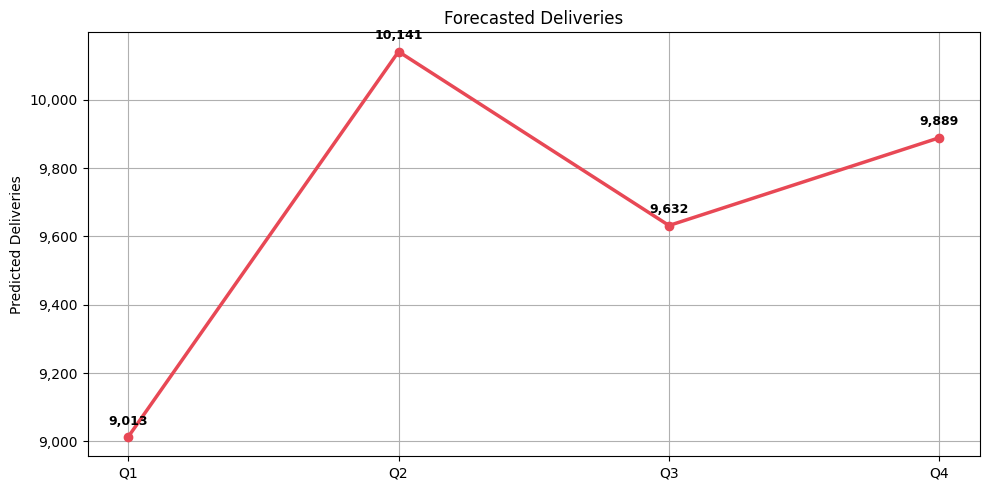

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(forecast_df['Forecast_Period'], forecast_df['Predicted_Deliveries'],
         marker='o', linewidth=2.5, color='#E84855')
for _, row in forecast_df.iterrows():
    plt.annotate(f"{row['Predicted_Deliveries']:,}",
                 (row['Forecast_Period'], row['Predicted_Deliveries']),
                 textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=9, fontweight='bold')
plt.title('Forecasted Deliveries')
plt.ylabel('Predicted Deliveries')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.grid(True)
plt.tight_layout()
plt.show()


### Forecasting Insight

The forecasting model predicts future Tesla deliveries by leveraging historical delivery patterns through lag features and rolling statistics. The projected values suggest the expected delivery trajectory over the next four quarters based on historical trends and operational indicators.

One caveat worth noting: the forecast is recursive, meaning each quarter's prediction feeds into the next as a lag value. This means error compounds as you go further out — Q1 is more reliable than Q4. These numbers are directional rather than precise, and should be paired with a scenario range (±10–15%) for any real planning purposes.


# Conclusion

- Tesla deliveries have grown substantially over the decade, but the trajectory has three distinct phases — early supply constraints, a mass-market inflection driven by Model 3/Y, and a recent plateau requiring demand-side management.
- Production and deliveries are strongly correlated; the gap between them is a practical early-warning indicator of pricing pressure.
- Charging infrastructure shows a consistent positive relationship with delivery volumes.
- Feature engineering using lag features and rolling statistics materially improved predictive capability.
- Ridge Regression outperformed Linear and Lasso on the test set, largely because L2 regularization handled the multicollinearity in the feature set better than unconstrained OLS.
- Cross-validation using TimeSeriesSplit confirmed the model generalises across different time windows, not just the specific test split.
- Forecasts indicate continued demand at a similar level, with Q1 being the most reliable projection.


# Business Recommendations

1. Continue expanding charging infrastructure in high-growth regions — the data supports treating this as demand generation, not just product support.

2. Focus production on the highest-demand vehicle models while maintaining premium models for margin.

3. Monitor the production–delivery gap monthly — widening over two or more quarters is a reliable signal to investigate demand-side interventions before inventory becomes a problem.

4. Use forecasting models for production planning and inventory management, with Q1–Q2 projections for firm commitments and Q3–Q4 for flexible capacity.

5. Monitor battery technology improvements — range and capacity improvements correlate positively with deliveries, particularly in markets with limited charging coverage.
